<a href="https://colab.research.google.com/github/SruthiGS-Gito/Case-Study---Assignment-MLAI-B3/blob/main/EDA_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preprocessing "House Pricing Dataset"

## Step 1 : Lord, Import and Understanding Dataset and necessary Libraries

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

In [42]:
df_house = pd.read_csv("/content/drive/MyDrive/AI ML/ICT_AI_ML/student_manager/data/House_Pricing.csv")

In [43]:
df_house

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,14 May 2017,360000.0,3,2.50,1530.0,1131.0,3.0,No,NaN,...,8,1530.0,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21609,6600060120,15 February 2016,400000.0,4,2.50,2310.0,5813.0,2.0,No,NaN,...,8,2310.0,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21610,1523300141,14 June 2017,402101.0,2,0.75,1020.0,1350.0,2.0,No,NaN,...,7,1020.0,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21611,291310100,15 January 2016,400000.0,3,2.50,1600.0,2388.0,2.0,No,NaN,...,8,1600.0,0,14,0,98027.0,47.5345,-122.069,1410.0,1287


In [44]:
df_house.info()   # returns : 1. Non-null, not the null count itself, 2) datatype

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [45]:
# Before clean/Preprocessing any column, for EVERY column we'll check:
# 1) What TYPE is it?
# 2) How much is MISSING ?
# 3) How many DIFFERENT values does it have ?


# We can calculate the percentage of missing values, why ?
# For example : 4 / 21613 * 100 = 0.02% -> small, can work with
#               19489 / 21613 * 100  = 90.18%  -> large, can be dropped

# unique values can be calculated : To know exactly how many actually different values exist here? Helps to determine suited encoding technique, Eg: In One-Hot encoding, every unique category becomes its own new column
# But doing it blindly on a column without checking uniqueness first, will result in abnormally high number of increase in columns other than the original number of columns

# DataFrame : Labeled Table (Dictionary)
metadata = pd.DataFrame({
#   column_name   :  column_data
    # "missing_value"     :  df_house.isna().sum(),  # How many values are missing in this column, adds up the True values per column (True=1, False=0)
    "missing_value_percentage" :  (df_house.isna().sum()/len(df_house)*100),  # What % of the column is missing, "len(df_house)" : total number of rows
    "unique"      :  df_house.nunique() # How many DIFFERENT values exist in the columns, "number of unique values", ('Bad','Fair','Okay','Good','Excellent') = 5
})

In [46]:
metadata

,missing_value_percentage,unique
ID,0.000000,21436
Date House was Sold,0.000000,13
Sale Price,0.018507,3625
No of Bedrooms,0.000000,13
No of Bathrooms,0.018507,30
Flat Area (in Sqft),0.041642,1036
Lot Area (in Sqft),0.041642,9778
No of Floors,0.000000,6
Waterfront View,0.000000,2
No of Times Visited,90.172581,4


In [47]:
df_house.shape

(21613, 21)

In [48]:
df_house.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


## Step 2 : Checking for Duplicated values

In [49]:
duplicate_id = df_house[df_house["ID"].duplicated()]

In [50]:
duplicate_id

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
94,6021501535,14 December 2017,700000.0,3,1.50,1580.0,5000.0,1.0,No,NaN,...,8,1290.0,290,79,0,98117.0,47.6870,-122.386,1570.0,4500
314,4139480200,14 December 2017,1400000.0,4,3.25,4290.0,12103.0,1.0,No,Thrice,...,10,2690.0,1600,21,0,98006.0,47.5503,-122.102,3860.0,11244
325,7520000520,15 March 2016,240500.0,2,1.00,1240.0,12092.0,1.0,No,NaN,...,6,960.0,280,96,1984,98146.0,47.4957,-122.352,1820.0,7460
346,3969300030,14 December 2017,239900.0,4,1.00,1000.0,7134.0,1.0,No,NaN,...,6,1000.0,0,75,0,98178.0,47.4897,-122.240,1020.0,7138
372,2231500030,15 March 2016,530000.0,4,2.25,NaN,10754.0,1.0,No,NaN,...,7,1100.0,1080,64,0,98133.0,47.7711,-122.341,1810.0,6929
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20181,7853400250,15 February 2016,645000.0,4,3.50,2910.0,5260.0,2.0,No,NaN,...,9,2910.0,0,6,0,98065.0,47.5168,-121.883,2910.0,5260
20613,2724049222,14 December 2017,220000.0,2,2.50,1000.0,1092.0,2.0,No,NaN,...,7,990.0,10,14,0,98118.0,47.5419,-122.271,1330.0,1466
20670,8564860270,15 March 2016,502000.0,4,2.50,2680.0,5539.0,2.0,No,NaN,...,8,2680.0,0,5,0,98045.0,47.4759,-121.734,2680.0,5992
20780,6300000226,15 May 2016,380000.0,4,1.00,1200.0,2171.0,1.5,No,NaN,...,7,1200.0,0,85,0,98133.0,47.7076,-122.342,1130.0,1598


In [51]:
duplicate_id = df_house[df_house["ID"].duplicated(keep=False)]

print(f"Rows sharing duplicate IDs : {duplicate_id.shape[0]}")
duplicate_id[["ID", "Date House was Sold", "Sale Price", "Flat Area (in Sqft)"]].head(10)

# duplicated marks duplicated rows as True, hence unique values as False, keep() is used to keep which parameter to be kept, therefore not marked as a duplicate
# keep() : To see all rows involved in duplicate IDs, not just the later occurrences, hence no keep="first" instead keep="False"
# whether : genuinely repeated transactions/data-entry was mistake
# Finding: same ID has different Date and Sale Price but identical area columns

Rows sharing duplicate IDs : 353


,ID,Date House was Sold,Sale Price,Flat Area (in Sqft)
93,6021501535,14 July 2017,430000.0,1580.0
94,6021501535,14 December 2017,700000.0,1580.0
313,4139480200,14 June 2017,1380000.0,4290.0
314,4139480200,14 December 2017,1400000.0,4290.0
324,7520000520,14 September 2017,232000.0,1240.0
325,7520000520,15 March 2016,240500.0,1240.0
345,3969300030,14 July 2017,165000.0,1000.0
346,3969300030,14 December 2017,239900.0,1000.0
371,2231500030,14 October 2017,315000.0,2180.0
372,2231500030,15 March 2016,530000.0,NaN


In [52]:
# Check complete duplicate rows
df_house.duplicated().sum()   # 0 -> No fully duplicated rows. Nothig to remove

np.int64(0)

## Step 3 : Dropping ID - Not a feature, but an identifier

In [53]:
df_house.drop(columns="ID", inplace=True)

## Step 4 : Missing Values Evaluation

In [54]:
df_house.isnull().sum().sort_values(ascending=False)

,0
No of Times Visited,19489
Flat Area (in Sqft),9
Lot Area (in Sqft),9
Sale Price,4
No of Bathrooms,4
Area of the House from Basement (in Sqft),3
Latitude,1
Longitude,1
Living Area after Renovation (in Sqft),1
Zipcode,1


In [55]:
# TARGET COLUMN : Sale Price
# Imputing a missing target would mean training on invented answers.
print("Rows with missing Sale Pric : ", df_house["Sale Price"].isna().sum())

Rows with missing Sale Pric :  4


In [56]:
df_house.dropna(subset=["Sale Price"], inplace=True)    # Removing rows where target is missing
print("Shape after dropping missing target rows : ", df_house.shape)

Shape after dropping missing target rows :  (21609, 20)


In [57]:
# Dropping 90% Missing Column i.e : 'No of Times Visited' is missing in 19,489 out of 21,609 rows (90.2%), no imputation method is credible here
print(f"'No of Times Visited' missing %: {df_house['No of Times Visited'].isna().mean()*100:.1f}%")
df_house.drop(columns="No of Times Visited", inplace=True)

'No of Times Visited' missing %: 90.2%


## Step 5 : Numerical and Categorical Columns

In [58]:
# Identifying
num_cols = df_house.select_dtypes(include=np.number).columns
cat_cols = df_house.select_dtypes(include="object").columns
print("Numerical columns :", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns : Index(['Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')
Categorical columns: Index(['Date House was Sold', 'Waterfront View', 'Condition of the House'], dtype='object')


## Step 6 : Imputation of Numerical features

In [59]:
# Imputation Numerical Features with : median() is used because it is less sensitive to outliers, compared to mean
df_house[num_cols] = df_house[num_cols].fillna(df_house[num_cols].median())
print("Missing values in numerical columns after imputation:", df_house[num_cols].isna().sum())

Missing values in numerical columns after imputation: Sale Price                                   0
No of Bedrooms                               0
No of Bathrooms                              0
Flat Area (in Sqft)                          0
Lot Area (in Sqft)                           0
No of Floors                                 0
Overall Grade                                0
Area of the House from Basement (in Sqft)    0
Basement Area (in Sqft)                      0
Age of House (in Years)                      0
Renovated Year                               0
Zipcode                                      0
Latitude                                     0
Longitude                                    0
Living Area after Renovation (in Sqft)       0
Lot Area after Renovation (in Sqft)          0
dtype: int64


## Step 7 : Imputation of categorical columns

In [60]:
# mode() - (most frequent value) : is used due to "dealing with categorical data", since mean/median are not applicable for text labels
df_house[cat_cols] = df_house[cat_cols].fillna(df_house[cat_cols].mode().iloc[0])
print("Total missing values remaining:", df_house.isna().sum())

Total missing values remaining: Date House was Sold                          0
Sale Price                                   0
No of Bedrooms                               0
No of Bathrooms                              0
Flat Area (in Sqft)                          0
Lot Area (in Sqft)                           0
No of Floors                                 0
Waterfront View                              0
Condition of the House                       0
Overall Grade                                0
Area of the House from Basement (in Sqft)    0
Basement Area (in Sqft)                      0
Age of House (in Years)                      0
Renovated Year                               0
Zipcode                                      0
Latitude                                     0
Longitude                                    0
Living Area after Renovation (in Sqft)       0
Lot Area after Renovation (in Sqft)          0
dtype: int64


## Step 8 : Converting Date column (object)

In [61]:
# Converting strings -> datetime
df_house["Date House was Sold"] = pd.to_datetime(df_house["Date House was Sold"])
# Now we can access individual components using .dt

In [62]:
# Extracting and Creating new features:
# yead and month are extracted because house prices can vary over time (price trends)
df_house["Year_Sold"] = df_house["Date House was Sold"].dt.year
df_house["Month_Sold"] = df_house["Date House was Sold"].dt.month

In [63]:
# Droping original date
df_house.drop(columns="Date House was Sold", inplace=True)

In [64]:
print(df_house[["Year_Sold", "Month_Sold"]].head())

   Year_Sold  Month_Sold
0       2017          10
1       2017          12
2       2016           2
3       2017          12
4       2016           2


In [65]:
# 'Renovated Year = 0' is not a real year, it means "never renovated" (over 20,000 rows). Treating 0 as a year would create a confusion 2000+ year gap
print(df_house["Renovated Year"].value_counts().head(3))

Renovated Year
0       20695
2014       91
2013       37
Name: count, dtype: int64


In [66]:
df_house["Was Renovated"] = (df_house["Renovated Year"] != 0).astype(int)
df_house.drop(columns="Renovated Year", inplace=True)

In [67]:
# 'Condition of the House' has order: Bad < Fair < Okay < Good < Excellent
# This is ORDINAL, not nominal, manual mapping preserves the order
# One-Hot encoding would lose this ordering information entirely

condition_order = {"Bad": 0, "Fair": 1, "Okay": 2, "Good": 3, "Excellent": 4}

In [68]:
df_house["Condition of the House"] = df_house["Condition of the House"].map(condition_order)
print(df_house["Condition of the House"].value_counts().sort_index())

Condition of the House
0       30
1    14028
2      172
3     5678
4     1701
Name: count, dtype: int64


In [69]:
# One-Hot Encoding — "Waterfront View"
cat_cols = df_house.select_dtypes(include="object").columns.tolist()
print("Remaining categorical columns:", cat_cols)

Remaining categorical columns: ['Waterfront View']


In [70]:
# "Waterfront View" is nominal with only 2 categories (Yes/No), drop_first=True removes one column to avoid multicollinearity
df_house = pd.get_dummies(df_house, columns=cat_cols, drop_first=True)
df_house.head()

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Year_Sold,Month_Sold,Was Renovated,Waterfront View_Yes
0,221900.0,3,1.00,1180.0,5650.0,1.0,1,7,1180.0,0,63,98178.0,47.5112,-122.257,1340.0,5650,2017,10,0,False
1,538000.0,3,2.25,2570.0,7242.0,2.0,1,7,2170.0,400,67,98125.0,47.7210,-122.319,1690.0,7639,2017,12,1,False
2,180000.0,2,1.00,770.0,10000.0,1.0,1,6,770.0,0,85,98028.0,47.7379,-122.233,2720.0,8062,2016,2,0,False
3,604000.0,4,3.00,1960.0,5000.0,1.0,4,7,1050.0,910,53,98136.0,47.5208,-122.393,1360.0,5000,2017,12,0,False
4,510000.0,3,2.00,1680.0,8080.0,1.0,1,8,1680.0,0,31,98074.0,47.6168,-122.045,1800.0,7503,2016,2,0,False


In [71]:
# Zipcode -> Target Encoding
# Zipcode is stored as a number but represents geography — its arithmetic mean is meaningless. Deleting it throws away one of the strongest real-world predictors of price
# Target Encoding replaces each zipcode with the mean Sale Price of that zipcode, turning it into a genuinely informative numeric feature
print("Unique zipcodes:", df_house["Zipcode"].nunique())
zipcode_avg_price = df_house.groupby("Zipcode")["Sale Price"].mean()

Unique zipcodes: 70


In [72]:
df_house["Zipcode_Price_Index"] = df_house["Zipcode"].map(zipcode_avg_price)
df_house.drop(columns="Zipcode", inplace=True)

In [73]:
print(df_house[["Zipcode_Price_Index", "Sale Price"]].corr())

                     Zipcode_Price_Index  Sale Price
Zipcode_Price_Index             1.000000    0.638208
Sale Price                      0.638208    1.000000


EXAMPLE : .get_dummies()

      Color
    1 - Red
    2 - Blue
    3 - Green

    Converted to :
    Color_Blue	Color_Green   Color_Red
    1 -  0           0	           1
    2 -  1           0             0
    3 -  0	         1  	       0

## Step 10 : One-hot encoding

EXAMPLE :
One-hot encoding creates:

    Exellent    	   Fair           Good
    1)   0	            0	            1
    2)   0        	    1	            0
    3)   1	            0    	        0

In [74]:
df_house.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21609 entries, 0 to 21612
Data columns (total 20 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Sale Price                                 21609 non-null  float64
 1   No of Bedrooms                             21609 non-null  int64  
 2   No of Bathrooms                            21609 non-null  float64
 3   Flat Area (in Sqft)                        21609 non-null  float64
 4   Lot Area (in Sqft)                         21609 non-null  float64
 5   No of Floors                               21609 non-null  float64
 6   Condition of the House                     21609 non-null  int64  
 7   Overall Grade                              21609 non-null  int64  
 8   Area of the House from Basement (in Sqft)  21609 non-null  float64
 9   Basement Area (in Sqft)                    21609 non-null  int64  
 10  Age of House (in Years)    

In [75]:
# Visualising helps confirms which columns are skewed, justifys which method to use for outlier detection
outlier_cols = [
    "Sale Price",
    "Flat Area (in Sqft)",
    "Lot Area (in Sqft)",
    "Area of the House from Basement (in Sqft)",
    "Basement Area (in Sqft)",
    "Living Area after Renovation (in Sqft)",
    "Lot Area after Renovation (in Sqft)"
]

# These columns are chosen because they are measurements whose values can vary continuously over a range,
# making them candidates for outlier analysis. Not absolute
# Question to ask is that :
# Does this feature represent a measurable quantity, whose unusually extreme values could distort the model?
# if yes : do outlier analysis otherwise don't

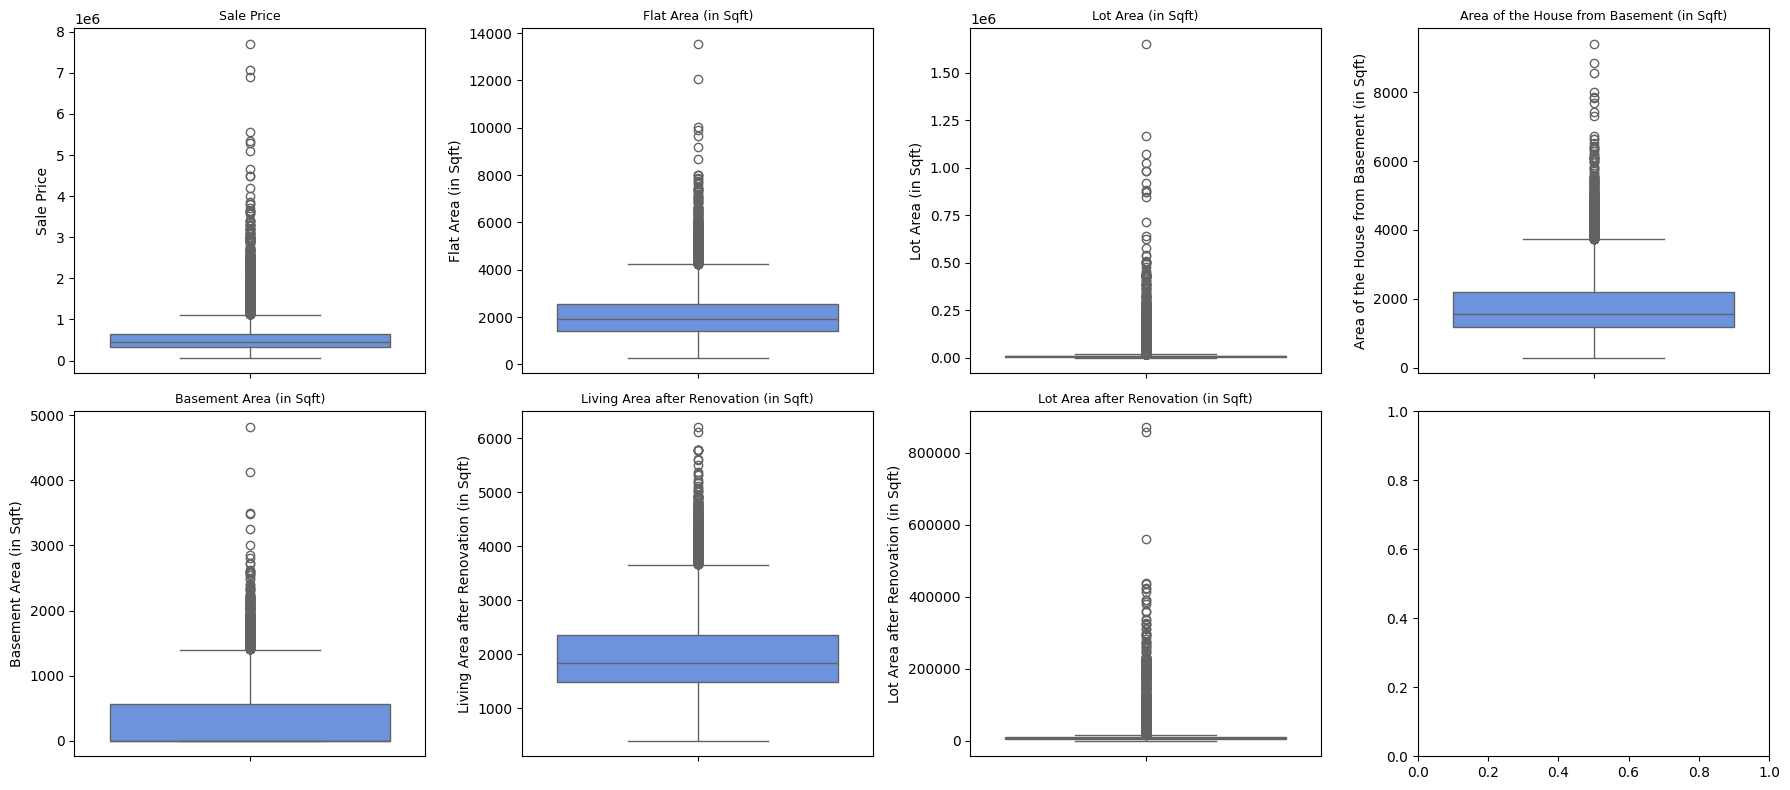

In [76]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), outlier_cols):
    sns.boxplot(y=df_house[col], ax=ax, color="#5b8dee")
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

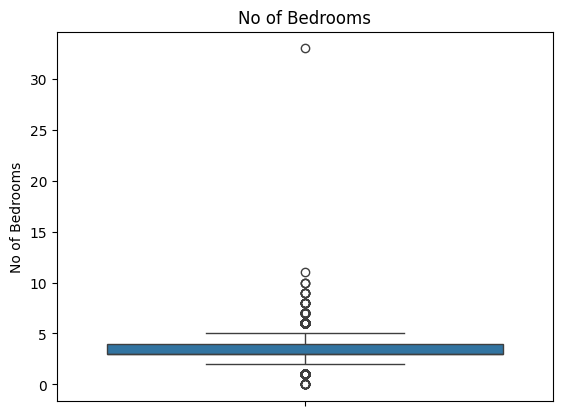

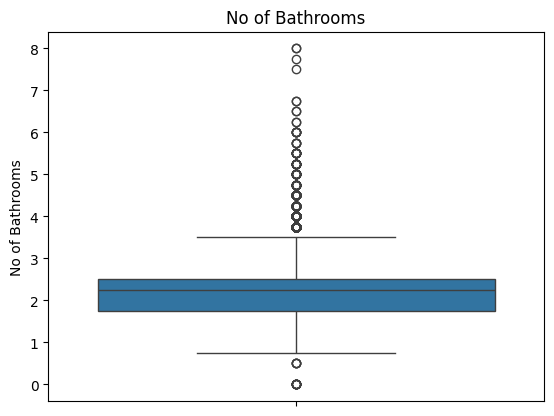

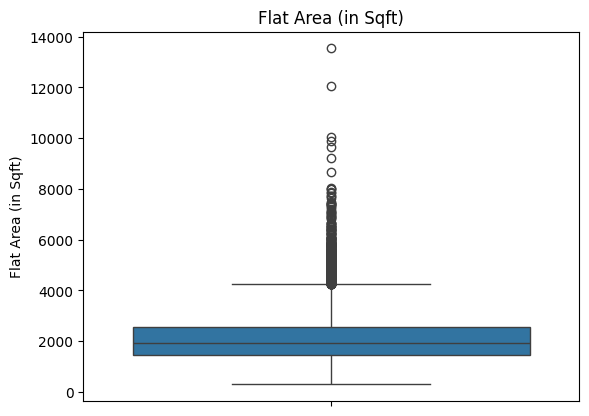

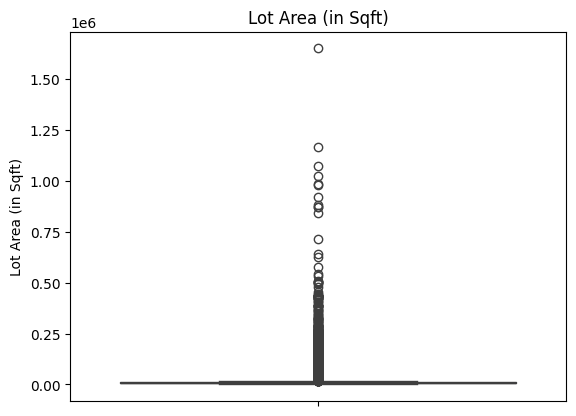

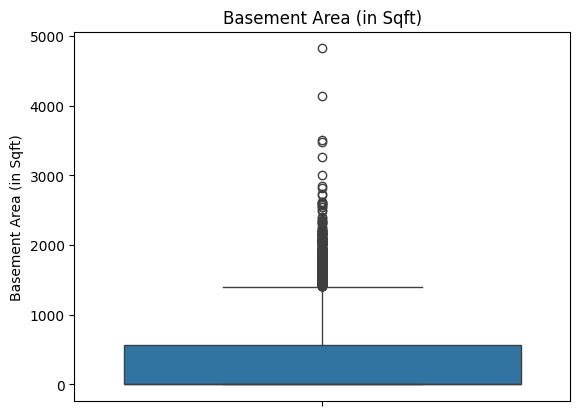

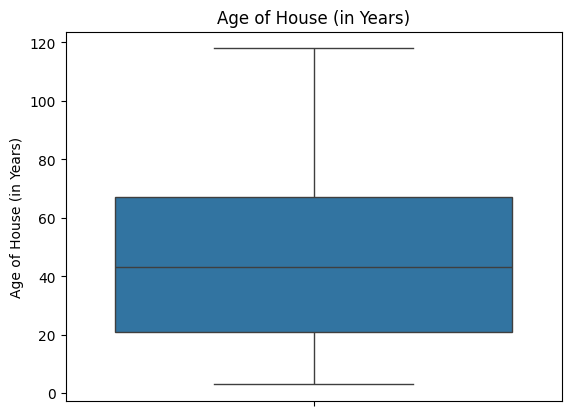

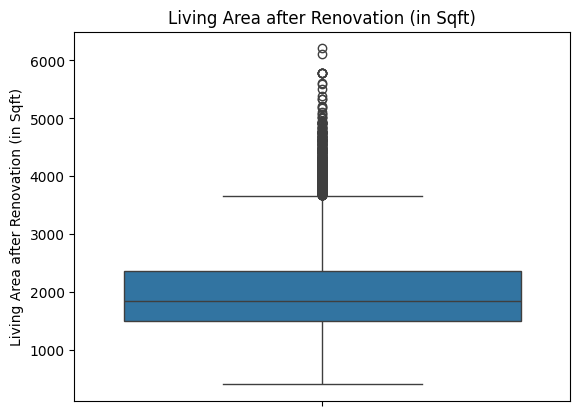

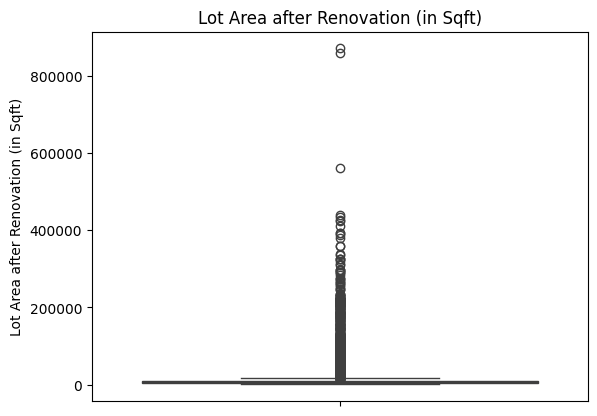

In [77]:
for col in continuous_cols:
  sns.boxplot(y=df_house[col])
  plt.title(col)
  plt.show()

In [78]:
print("\nSkew values : ")
print(df_house[outlier_cols].skew().sort_values(ascending=False))


Skew values : 
Lot Area (in Sqft)                           13.059616
Lot Area after Renovation (in Sqft)           9.505931
Sale Price                                    4.021472
Basement Area (in Sqft)                       1.578058
Flat Area (in Sqft)                           1.472391
Area of the House from Basement (in Sqft)     1.446943
Living Area after Renovation (in Sqft)        1.108228
dtype: float64


In [79]:
# Near 0 : Approximately symmetric
# -0.5 < skew < 0.5

## Step 11 : Outlier removal

In [80]:
# Continuous area and price-related features exhibiting stronger positive skew.
# These columns are potential candidates for IQR-based outlier treatment,
# since extreme values can disproportionately influence regression models.
outlier_cols = [
    "Sale Price",
    "Flat Area (in Sqft)",
    "Lot Area (in Sqft)",
    "Area of the House from Basement (in Sqft)",
    "Basement Area (in Sqft)",
    "Living Area after Renovation (in Sqft)",
    "Lot Area after Renovation (in Sqft)"
]

In [81]:
rows_before = df_house.shape[0]

In [82]:
rows_before = df_house.shape[0]

for col in outlier_cols:
  Q1 = df_house[col].quantile(0.25)
  Q3 = df_house[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  df_house = df_house[(df_house[col] >= lower) & (df_house[col] <= upper)]

rows_after = df_house.shape[0]
print(f"Rows before : {rows_before}")
print(f"Rows after  : {rows_after}")
print(f"Removed     : {rows_before - rows_after}  ({(rows_before - rows_after)/rows_before*100:.1f}%)")

Rows before : 21609
Rows after  : 16615
Removed     : 4994  (23.1%)


In [83]:
df_house[outlier_cols].skew().sort_values(key=abs, ascending=False)

,0
Basement Area (in Sqft),1.190788
Sale Price,0.832372
Area of the House from Basement (in Sqft),0.796883
Living Area after Renovation (in Sqft),0.564537
Flat Area (in Sqft),0.405218
Lot Area (in Sqft),0.403957
Lot Area after Renovation (in Sqft),0.087780


## Step 12 : Splitting [X and y] i.e : Splitting Features and Target

In [84]:
X = df_house.drop(columns="Sale Price")
y = df_house["Sale Price"]

## Step 13 : Train-test split

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

# If we scaled on the full dataset first, the test set's statistics would influence how training data gets scaled
# The model would indirectly see test data it's supposed to have never encountered

X_train: (13292, 19)
X_test : (3323, 19)


In [86]:
# Scale Numerical Features

# StandardScaler is chosen over MinMaxScaler because residual skew remains after outlier removal; MinMaxScaler's range is easily compressed by a single remaining extreme value.

binary_like_cols = [c for c in X.columns if X[c].nunique() <= 2]    # list comprehension
scale_cols = [c for c in X.columns if c not in binary_like_cols]    # list comprehension

In [87]:
print("Excluded from scaling (binary/dummy):", binary_like_cols)
print("Scaled (continuous):", scale_cols)

Excluded from scaling (binary/dummy): ['Year_Sold', 'Was Renovated', 'Waterfront View_Yes']
Scaled (continuous): ['No of Bedrooms', 'No of Bathrooms', 'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors', 'Condition of the House', 'Overall Grade', 'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)', 'Age of House (in Years)', 'Latitude', 'Longitude', 'Living Area after Renovation (in Sqft)', 'Lot Area after Renovation (in Sqft)', 'Month_Sold', 'Zipcode_Price_Index']


In [88]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

In [89]:
# fit_transform on train only, then transform (not fit) on test
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols]  = scaler.transform(X_test[scale_cols])